# A3.2 2020 折诊断

本 notebook 只读取本地年度研究制品，不访问网络，也不导出个股信号、目标权重或持仓。

**结论摘要**

- 2020 折的 A0 与 A3.2 两个任务均已完成；年度研究仍有 2021—2025 共 10 个待运行任务。
- A3.2 在 11 次有效拟合中均未通过候选袖套的样本外净增量门槛，因此实际候选权重始终为 0。
- A3.2 的目标权重、持仓、成交、优化结果和逐日净值与冻结 A0 完全一致，证明保护机制生效，但没有产生新增 alpha。
- A3.1 曾降低 2020 年化主动收益并提高换手与成本；A3.2 修复了该退化，但当前候选因子仍不具备可用的增量证据。


## 1. 数据与方法

比较对象为同一 2020 验证折下的冻结基线 A0、上一版残差袖套 A3.1 与带换手预算和样本外门控的 A3.2。质量检查覆盖任务状态、关键制品完整性、日频主键、空值、冻结基线跨研究复现，以及 A3.2 与 A0 的经济制品一致性。


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO = Path.cwd()
if not (REPO / "annual-studies").exists():
    REPO = REPO.parent
ANNUAL = REPO / "annual-studies"
A32_ROOT = ANNUAL / "a32-turnover-budgeted-residual-v1-annual-2020-2025"
A31_ROOT = ANNUAL / "a31-residual-sleeve-v1-annual-2020-2025"
RUNS = {
    "A0": A32_ROOT / "folds/2020/a0_frozen_reference/attempt-001",
    "A3.1": A31_ROOT / "folds/2020/a31_residual_sleeve/attempt-001",
    "A3.2": A32_ROOT / "folds/2020/a32_turnover_budgeted_residual/attempt-001",
}
A0_PREVIOUS = A31_ROOT / "folds/2020/a0_frozen_reference/attempt-001"


def load_json(path):
    return json.loads(path.read_text(encoding="utf-8"))


RUNS

{'A0': WindowsPath('D:/PKU/quant/factor-project-csi500/annual-studies/a32-turnover-budgeted-residual-v1-annual-2020-2025/folds/2020/a0_frozen_reference/attempt-001'),
 'A3.1': WindowsPath('D:/PKU/quant/factor-project-csi500/annual-studies/a31-residual-sleeve-v1-annual-2020-2025/folds/2020/a31_residual_sleeve/attempt-001'),
 'A3.2': WindowsPath('D:/PKU/quant/factor-project-csi500/annual-studies/a32-turnover-budgeted-residual-v1-annual-2020-2025/folds/2020/a32_turnover_budgeted_residual/attempt-001')}

## 2. 完整性与可复现性检查


In [2]:
required_files = [
    "metrics.json",
    "run-manifest.json",
    "daily.parquet",
    "evaluation-signals.parquet",
    "targets.parquet",
    "positions.parquet",
    "trades.parquet",
    "optimization.parquet",
    "model-fits.parquet",
]
progress = load_json(A32_ROOT / "progress.json")
quality_rows = []
for label, run in RUNS.items():
    daily = pd.read_parquet(run / "daily.parquet")
    missing = [name for name in required_files if not (run / name).exists()]
    quality_rows.append(
        {
            "方法": label,
            "缺失关键制品": len(missing),
            "日频观测": len(daily),
            "起始日": str(daily["trade_date"].min()),
            "结束日": str(daily["trade_date"].max()),
            "日期重复": int(daily["trade_date"].duplicated().sum()),
            "关键收益空值": int(
                daily[["portfolio_return", "benchmark_return", "active_return"]].isna().sum().sum()
            ),
        }
    )
quality = pd.DataFrame(quality_rows)
display(quality)
print("年度任务状态：", progress)

economic_files = [
    "daily.parquet",
    "evaluation-signals.parquet",
    "targets.parquet",
    "positions.parquet",
    "trades.parquet",
    "optimization.parquet",
]
baseline_reproduction = {
    name: pd.read_parquet(RUNS["A0"] / name).equals(pd.read_parquet(A0_PREVIOUS / name))
    for name in economic_files
}
print("A0 跨研究根目录精确复现：", baseline_reproduction)

,方法,缺失关键制品,日频观测,起始日,结束日,日期重复,关键收益空值
0,A0,0,239,20200108,20201231,0,0
1,A3.1,0,239,20200108,20201231,0,0
2,A3.2,0,239,20200108,20201231,0,0


年度任务状态： {'annual_id': 'a32-turnover-budgeted-residual-v1-annual-2020-2025', 'completed_tasks': 2, 'pending_tasks': 10, 'schema_version': 1, 'stage': 'annual_tasks', 'status': 'incomplete', 'updated_at': '2026-08-30T07:40:54+00:00'}
A0 跨研究根目录精确复现： {'daily.parquet': True, 'evaluation-signals.parquet': True, 'targets.parquet': True, 'positions.parquet': True, 'trades.parquet': True, 'optimization.parquet': True}


## 3. 绩效与成本比较

主动收益、回撤和信息比率均基于 2020 验证折。交易成本为该折回测期内累计建模成本；平均换手沿用项目指标定义。


In [3]:
metric_fields = [
    "annualized_active_return",
    "information_ratio",
    "active_max_drawdown",
    "average_turnover",
    "transaction_cost",
    "tracking_error",
    "capm_alpha_annualized",
    "capm_beta",
]
metrics = pd.DataFrame(
    {
        label: {field: load_json(run / "metrics.json")[field] for field in metric_fields}
        for label, run in RUNS.items()
    }
).T
metrics["主动收益相对A0变化(bp)"] = (
    metrics["annualized_active_return"] - metrics.loc["A0", "annualized_active_return"]
) * 10_000
metrics["成本相对A0变化(bp)"] = (
    metrics["transaction_cost"] - metrics.loc["A0", "transaction_cost"]
) * 10_000
metrics["换手相对A0变化"] = metrics["average_turnover"] / metrics.loc["A0", "average_turnover"] - 1
display(metrics.round(6))

,annualized_active_return,information_ratio,active_max_drawdown,average_turnover,transaction_cost,tracking_error,capm_alpha_annualized,capm_beta,主动收益相对A0变化(bp),成本相对A0变化(bp),换手相对A0变化
A0,0.017031,0.343622,-0.060474,0.026890,0.008761,0.053259,0.032551,0.904340,0.000000,0.00000,0.000000
A3.1,0.009876,0.223847,-0.044744,0.044244,0.014454,0.049310,0.021998,0.926496,-71.555253,56.93281,0.645384
A3.2,0.017031,0.343622,-0.060474,0.026890,0.008761,0.053259,0.032551,0.904340,0.000000,0.00000,0.000000


## 4. A3.2 门控路径

候选权重先由全样本目标产生，再由嵌套样本外净增量检验决定是否启用；只有通过证据门槛后，换手预算才可能进一步收缩权重。


In [4]:
fits = pd.read_parquet(RUNS["A3.2"] / "model-fits.parquet")
fit_rows = []
for row in fits.loc[fits["status"].eq("fitted")].itertuples(index=False):
    params = json.loads(row.model_parameters)
    evidence = params["sleeve_evidence"]
    budget = evidence["turnover_budget"]
    fit_rows.append(
        {
            "拟合日": str(row.fit_date),
            "阶段": row.experiment_phase,
            "全样本候选权重": evidence["raw_candidate_share"],
            "样本外t值": evidence["oof_t"],
            "样本外平均净增量": evidence["oof_mean_net_increment"],
            "正增量块占比": evidence["oof_positive_block_fraction"],
            "证据通过": evidence["oof_evidence_passed"],
            "最终候选权重": params["candidate_share"],
            "换手预算约束生效": budget["binding"],
        }
    )
fit_diagnostics = pd.DataFrame(fit_rows)
display(fit_diagnostics.round(6))
print("有效拟合次数：", len(fit_diagnostics))
print("证据通过次数：", int(fit_diagnostics["证据通过"].sum()))
print("最终候选权重大于 0 的次数：", int((fit_diagnostics["最终候选权重"] > 0).sum()))

,拟合日,阶段,全样本候选权重,样本外t值,样本外平均净增量,正增量块占比,证据通过,最终候选权重,换手预算约束生效
0,20190401,train,0.319668,-0.165121,-0.000198,0.500000,False,0.0,False
1,20190423,train,0.320505,-0.157787,-0.000174,0.500000,False,0.0,False
2,20190524,train,0.333097,-0.596191,-0.000733,0.000000,False,0.0,False
3,20190624,train,0.319753,-0.758567,-0.001134,0.500000,False,0.0,False
4,20190722,train,0.194404,-0.830160,-0.001267,0.500000,False,0.0,False
5,20190819,train,0.237170,-0.983158,-0.001464,0.500000,False,0.0,False
6,20190917,train,0.236658,-0.576552,-0.000895,0.500000,False,0.0,False
7,20191022,train,0.307529,-1.019570,-0.001447,0.000000,False,0.0,False
8,20191119,train,0.163220,-2.951121,-0.002458,0.000000,False,0.0,False
9,20191217,train,0.215490,-1.166259,-0.000829,0.000000,False,0.0,False


有效拟合次数： 11
证据通过次数： 0
最终候选权重大于 0 的次数： 0


## 5. 经济制品一致性


In [5]:
comparison_rows = []
for name in economic_files:
    a0 = pd.read_parquet(RUNS["A0"] / name)
    a32 = pd.read_parquet(RUNS["A3.2"] / name)
    numeric = [
        col
        for col in a0.columns.intersection(a32.columns)
        if (
            pd.api.types.is_numeric_dtype(a0[col])
            and pd.api.types.is_numeric_dtype(a32[col])
            and not pd.api.types.is_bool_dtype(a0[col])
            and not pd.api.types.is_bool_dtype(a32[col])
        )
    ]
    excluded_audit = {"selected_factor_count"}
    economic_numeric = [col for col in numeric if col not in excluded_audit]
    max_diff = 0.0
    for col in economic_numeric:
        diff = np.abs(
            pd.to_numeric(a0[col], errors="coerce") - pd.to_numeric(a32[col], errors="coerce")
        )
        finite = diff[np.isfinite(diff)]
        if len(finite):
            max_diff = max(max_diff, float(finite.max()))
    comparison_rows.append(
        {
            "制品": name,
            "A0行数": len(a0),
            "A3.2行数": len(a32),
            "经济数值最大绝对差": max_diff,
        }
    )
artifact_comparison = pd.DataFrame(comparison_rows)
display(artifact_comparison)

,制品,A0行数,A3.2行数,经济数值最大绝对差
0,daily.parquet,239,239,0.0
1,evaluation-signals.parquet,24000,24000,0.0
2,targets.parquet,10225,10225,0.0
3,positions.parquet,24062,24062,0.0
4,trades.parquet,11197,11197,0.0
5,optimization.parquet,48,48,0.0


## 6. 主动净值路径


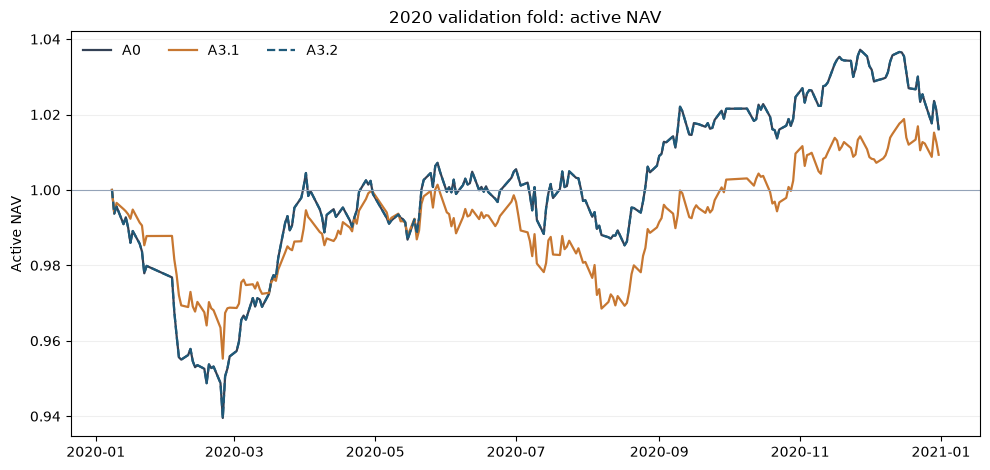

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.8))
styles = {"A0": ("#334155", "-"), "A3.1": ("#c77731", "-"), "A3.2": ("#1f5a7a", "--")}
for label, run in RUNS.items():
    daily = pd.read_parquet(run / "daily.parquet").copy()
    daily["trade_date"] = pd.to_datetime(daily["trade_date"].astype(str))
    color, linestyle = styles[label]
    ax.plot(
        daily["trade_date"],
        daily["active_nav"],
        label=label,
        color=color,
        linestyle=linestyle,
        linewidth=1.6,
    )
ax.axhline(1.0, color="#94a3b8", linewidth=0.8)
ax.set_title("2020 validation fold: active NAV")
ax.set_ylabel("Active NAV")
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
plt.show()

## 7. 结论与边界

1. **工程结论：通过。** 任务制品完整，冻结基线跨研究精确复现，A3.2 的回退路径没有改变任何经济输出。
2. **研究结论：A3.2 是有效的保护机制，不是有效的增益模型。** 它避免了 A3.1 在 2020 折上的收益与成本退化，但没有创造新增收益。
3. **瓶颈在候选信号，不在换手预算。** 11 次拟合的样本外证据全部失败，换手预算从未成为绑定约束；继续调预算参数不会解决核心问题。
4. **当前不应开启 2021—2025。** 先按预注册规则停止 A3.2 分支，回到候选因子池与准入研究；否则只会重复得到 A0。
5. **结论仅适用于 2020 开发折。** 年度选择与发布门禁仍显示 pending，是因为其余年份尚未运行，并非该折质量失败。
